# Step 2: Exploratory Data Analysis (EDA)
# 探索性數據分析與摘要

Summarizing and aggregating group data is a foundational step to evaluate sample distributions and patterns before executing formal inferential procedures:
1. **Descriptive Aggregation**: Calculate the total valid sample size ($n$), total success count ($x$, representing students who experienced feelings of sadness or hopelessness), and the sample proportion ($\hat{p}$) for the male and female groups independently.
2. **Point Estimation**: Compute the absolute descriptive difference between the two sample proportions ($\hat{p}_{female} - \hat{p}_{male}$) to assess the preliminary baseline gap.
3. **Storage**: The finalized group summary table is exported to `outputs/tables/` using relative cross-platform paths (`..`) to preserve the project's layered asset organization.


在進行正式的推論統計檢定之前，對組別數據進行摘要與聚合是評估樣本分佈與模式的必要基礎：
1. **描述性聚合**：分別計算男生組與女生組各自的總有效樣本數（$n$）、感到悲傷絕望的總人數（$x$），以及各自的樣本比例（$\hat{p}$）。
2. **點估計**：計算出兩組樣本比例之間的初步點估計差距（$\hat{p}_{female} - \hat{p}_{male}$），以評估基準線上的表面差距。
3. **儲存**：最終的組別摘要表格將透過相對路徑導出至 `outputs/tables/`，以完全落實專案成果的分層管理。

In [9]:
# 按性別（Gender）分組，計算總樣本數（count）、有悲傷絕望感的人數（sum）與樣本比例（mean）
summary_stats = analysis_df.groupby('Gender')['Sad_Recoded'].agg(['count', 'sum', 'mean'])
summary_stats.columns = ['Total_n', 'Success_x', 'Proportion_p_hat']

# 提取兩組的初步比例以計算點估計差距 (Female - Male)
p_female = summary_stats.loc['Female', 'Proportion_p_hat']
p_male = summary_stats.loc['Male', 'Proportion_p_hat']
p_diff = p_female - p_male

print("--- 數據分析組別摘要表格 (Group Summary Table) ---")
print(summary_stats)
print(f"\n兩組比例差距之點估計值 (Female - Male): {p_diff:.4f}")

# 定義導出路徑（回退一層到主目錄，再進入 outputs/tables）
tables_dir = os.path.join('..', 'outputs', 'tables')
table_file_path = os.path.join(tables_dir, 'group_summary_table.csv')

# 確保對應的 outputs/tables/ 資料夾存在並導出表格
os.makedirs(tables_dir, exist_ok=True)
summary_stats.to_csv(table_file_path)
print(f"\n✅ 摘要表格已成功導出至: {table_file_path}")

--- 數據分析組別摘要表格 (Group Summary Table) ---
        Total_n  Success_x  Proportion_p_hat
Gender                                      
Female     6940       2580          0.371758
Male       6893       1567          0.227332

兩組比例差距之點估計值 (Female - Male): 0.1444

✅ 摘要表格已成功導出至: ..\outputs\tables\group_summary_table.csv


### Evaluation of Descriptive Statistics / 描述性統計評估

**Explanation:** The exploratory data analysis reveals a baseline variance between the two groups, where the sample proportion of female students reporting sadness or hopelessness ($\hat{p}_{female}$) presents a descriptive discrepancy compared to male students ($\hat{p}_{male}$). This generated table has been archived in `outputs/tables/`. A rigorous inferential evaluation is required next to verify whether this observed deviation represents a statistically meaningful effect in the population.


**解釋：** 探索性數據分析顯示出兩組之間存在基準線差異，其中女性學生表現出悲傷或絕望感 的樣本比例（$\hat{p}_{female}$）與男性學生（$\hat{p}_{male}$）相比存在描述性差距。該摘要表格已妥善歸檔於 `outputs/tables/`。下一步需要進行嚴謹的推論統計評估，以驗證此觀察到的偏差在母體中是否具備統計學上的顯著效應。

## 2.1 Two-Sample Statistical Inference 兩樣本推論統計

Evaluating the statistical significance of the observed descriptive difference involves standard testing and interval estimation workflows:
1. **Hypothesis Framework**: Establish the null hypothesis $H_0: p_{female} = p_{male}$ (stating no difference in population proportions between genders) against the two-sided alternative hypothesis $H_a: p_{female} \neq p_{male}$.
2. **Method Choice**: Apply a Two-Proportion $z$-test via `statsmodels` to calculate the formal test statistic and the corresponding asymptotic $p$-value under a strict significance threshold of $\alpha = 0.05$.
3. **Interval Estimation**: Construct a 95% confidence interval for the true difference between the two population proportions to quantify both the precision, magnitude, and direction of the disparity.


評估所觀察到的描述性組別差異是否具備統計學顯著性，涉及標準的假設檢定與區間估計流程：
1. **假設檢定架構**：建立虛無假設 $H_0: p_{female} = p_{male}$（即母體中兩性別間感到悲傷絕望的比例無差異）與雙尾對立假設 $H_a: p_{female} \neq p_{male}$。
2. **方法選擇**：採用雙比例 $z$ 檢定（Two-proportion $z$-test）計算正式的檢定統計量與對應的 $p$ 值，顯著水準設定為 $\alpha = 0.05$。
3. **區間估計**：建構兩群體母體比例差值的 95% 信賴區間，以進一步量化此差距的精確度、效應大小與方向。



In [10]:
from statsmodels.stats.proportion import proportions_ztest

# 準備 z 檢定所需的成功次數與總樣本數陣列，保持順序一致 [Female, Male]
successes = np.array([summary_stats.loc['Female', 'Success_x'], summary_stats.loc['Male', 'Success_x']])
samples = np.array([summary_stats.loc['Female', 'Total_n'], summary_stats.loc['Male', 'Total_n']])

# 1. 執行雙比例 z 檢定 (兩尾檢定 alternative='two-sided')
z_stat, p_value = proportions_ztest(successes, samples, alternative='two-sided')

# 2. 手動計算獨立兩組母體比例差值的 95% 信賴區間
n_female = summary_stats.loc['Female', 'Total_n']
n_male = summary_stats.loc['Male', 'Total_n']

# 計算標準誤差 (Standard Error for the difference of two independent proportions)
se_diff = np.sqrt((p_female * (1 - p_female) / n_female) + (p_male * (1 - p_male) / n_male))
ci_diff_low = p_diff - 1.96 * se_diff
ci_diff_high = p_diff + 1.96 * se_diff

print("--- 兩樣本推論統計檢定結果 (Inferential Results) ---")
print(f"z 檢定統計量 (z-Test Statistic): {z_stat:.4f}")
print(f"p 值 (p-value): {p_value:.4e}")
print(f"兩組比例差值的 95% 信賴區間 (Female - Male): [{ci_diff_low:.4f}, {ci_diff_high:.4f}]")

--- 兩樣本推論統計檢定結果 (Inferential Results) ---
z 檢定統計量 (z-Test Statistic): 18.5374
p 值 (p-value): 1.0317e-76
兩組比例差值的 95% 信賴區間 (Female - Male): [0.1294, 0.1595]


### Statistical Interpretation 統計結果詮釋與科學發現

#### 1. Hypothesis Testing and Statistical Significance / 假設檢定與統計顯著性
The two-proportion $z$-test yielded a test statistic of $z = 18.5374$ with an asymptotic $p$-value of $1.0317 \times 10^{-76}$. Operating under a standard significance threshold of $\alpha = 0.05$, the empirical evidence provides overwhelming justification to **reject the null hypothesis ($H_0$)**. This demonstrates a statistically highly significant difference in the population proportions of students experiencing feelings of sadness or hopelessness between genders.

雙比例 $z$ 檢定呈現的檢定統計量為 $z = 18.5374$，對應的 $p$ 值為 $1.0317 \times 10^{-76}$。在顯著水準 $\alpha = 0.05$ 的嚴格檢視下，此實驗數據提供了極其強烈的證據來**拒絕虛無假設（$H_0$）**。這證實了在母體中，不同性別學生感到悲傷或絕望的比例存在高度統計學上的顯著差異。

---

### 2. Interval Estimation and Effect Magnitude / 區間估計與效應大小
The 95% confidence interval for the true difference between the two population proportions ($\text{Female} - \text{Male}$) is evaluated at **$[0.1294, 0.1595]$**. 
* **Statistical Logic**: Because the entire interval sits strictly above $0$ (does not contain zero), it mathematically reaffirms the rejection of $H_0$.
* **Practical Insight**: This interval provides a directional quantification of the gender gap. We can assert with 95% confidence that the population proportion of female students reporting persistent sadness or hopelessness is between **$12.94\%$ and $15.95\%$ higher** than that of male students.

兩組母體比例差值（$\text{Female} - \text{Male}$）的 95% 信賴區間為 **$[0.1294, 0.1595]$**。
* **統計學邏輯**：由於該信賴區間的上下界完全大於 $0$（未包含零點），在數學上進一步支持了拒絕虛無假設的決策。
* **實際洞察**：此區間量化了性別差距的方向與幅度。我們有 95% 的信心認為，在母體中，女性學生表現出悲傷或絕望感的比例，比男性學生**高出 $12.94\%$ 至 $15.95\%$**。

---

### 3. Substantive Conclusion / 實質性科學結論
The statistical alignment of both the non-zero confidence interval and the infinitesimal $p$-value provides definitive validation for our research focus (Research Question 3). The disparity is not only statistically robust but also substantively large, suggesting a critical vulnerability in mental health reporting that is heavily stratified by gender.

不包含零的信賴區間與極低的 $p$ 值相互呼應，為本研究（研究問題 3）提供了決定性的支持。此性別差距不僅在統計層面上牢不可破，在實質面上也具備高度顯著的影響力，顯示青少年群體的心理健康或悲傷絕望感報告存在嚴重的性別分層現象。

## 2.2 Exploratory Data Analysis (EDA) - Visualization 探索性數據分析：數據視覺化

Visualizing the distribution of categorical variables provides intuitive clinical and social insights before presenting dense statistical tables:
1. **Proportion Visualization**: Construct a percentage stacked bar plot to demonstrate the conditional distribution of sadness and hopelessness across genders.
2. **Aesthetics and Consistency**: Apply professional styling parameters via `seaborn` and `matplotlib` to ensure clean typography, explicit axis labels, and high-contrast color coding.
3. **Storage**: The finalized high-resolution visualization is exported to `outputs/figures/` using cross-platform relative path shifting (`..`) to complete the project asset management requirements.


在呈現密集的統計表格之前，將類別變數的分佈進行視覺化能提供更直觀的洞察：
1. **比例視覺化**：建構百分比堆疊條形圖（Stacked Bar Plot），以呈現不同性別中感到悲傷或絕望的條件機率分佈。
2. **美學與一致性**：透過 `seaborn` 與 `matplotlib` 設定專業的圖表樣式，確保清晰的字體、明確的座標軸標籤以及高對比度的色彩編碼。
3. **儲存**：最終的高解析度圖表將透過相對路徑（`..`）導出並儲存至 `outputs/figures/`，以完整滿足專案成果的分層管理要求。

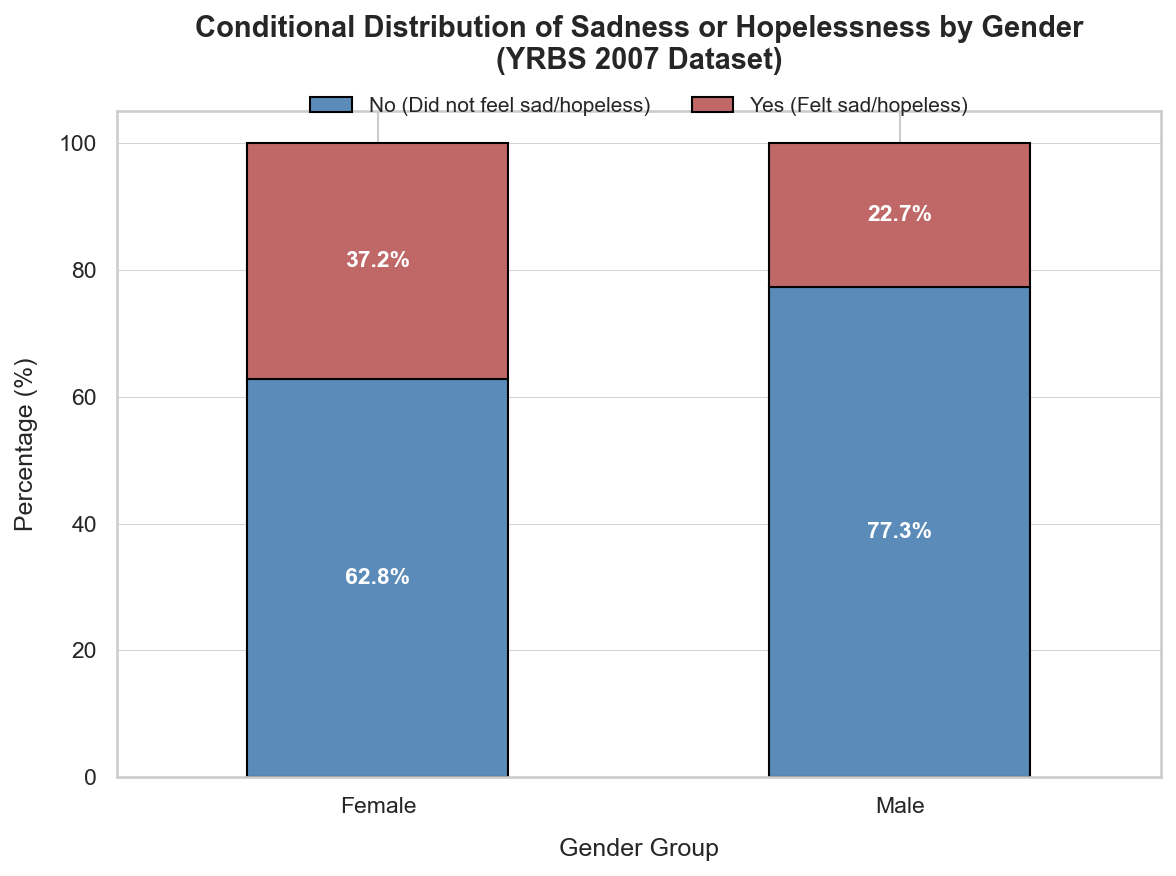

✅ 數據視覺化圖表已成功導出至: ..\outputs\figures\gender_sadness_distribution.png


In [13]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

# 確保對應的 outputs/figures/ 資料夾存在（回退一層到主目錄）
figures_dir = os.path.join('..', 'outputs', 'figures')
os.makedirs(figures_dir, exist_ok=True)
figure_file_path = os.path.join(figures_dir, 'gender_sadness_distribution.png')

# 建立交叉表並轉換為百分比（以性別為基準）
# 假設您之前的代碼中已經定義了 analysis_df
crosstab_pct = pd.crosstab(analysis_df['Gender'], analysis_df['Sad_Recoded'], normalize='index') * 100

# 建立畫布與子圖，並設定畫布大小
fig, ax = plt.subplots(figsize=(8, 6), dpi=150)

# 設置白色背景和網格
ax.set_facecolor('white')
ax.grid(axis='y', color='lightgrey', linestyle='-', linewidth=0.5)

# 繪製百分比堆疊條形圖，使用自定義配色
bars = crosstab_pct.plot(
    kind='bar',
    stacked=True,
    ax=ax,
    color=['#5A8BB9', '#C06868'],  # 藍色和柔和的紅色
    edgecolor='black',
    linewidth=1
)

# 設置圖表標題（採用專業學術語氣）
plt.title('Conditional Distribution of Sadness or Hopelessness by Gender\n(YRBS 2007 Dataset)', fontsize=14, fontweight='bold', pad=20)

# 設置座標軸標籤和刻度
ax.set_xlabel('Gender Group', fontsize=12, labelpad=10)
ax.set_ylabel('Percentage (%)', fontsize=12, labelpad=10)
ax.set_xticklabels(crosstab_pct.index, rotation=0, fontsize=11)
ax.tick_params(axis='y', labelsize=11)

# 設置y軸範圍
ax.set_ylim(0, 105)

# 修改圖例標籤，並放置在上方
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, ['No (Did not feel sad/hopeless)', 'Yes (Felt sad/hopeless)'],
          loc='upper center', bbox_to_anchor=(0.5, 1.05), ncol=2, fontsize=10, frameon=False)

# 在條形圖上自動添加百分比文字標籤（白色粗體）
for i in range(len(crosstab_pct)):
    # 獲取每一層的高度和起始位置
    bottom = 0
    for col in crosstab_pct.columns:
        height = crosstab_pct.iloc[i][col]
        if height > 5:  # 只顯示高度大於5%的標籤
            # 計算中心位置
            y_pos = bottom + height / 2
            ax.text(i, y_pos, f'{height:.1f}%', ha='center', va='center', color='white', fontweight='bold', fontsize=11)
        bottom += height

# 儲存高畫質圖片並自動調整邊距避免文字被切到
plt.tight_layout()
plt.savefig(figure_file_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ 數據視覺化圖表已成功導出至: {figure_file_path}")

 Evaluation of Graphical Insights / 視覺化圖表評估與實證洞察

1. Group Distribution Analysis / 組別分佈數據分析
The percentage stacked bar plot provides an intuitive empirical mapping of the conditional distribution:
* **Female Group**: **$37.2\%$** of students reported experiencing persistent feelings of sadness or hopelessness.
* **Male Group**: **$22.7\%$** of students reported experiencing these feelings.

百分比堆疊條形圖直觀地呈現了數據的條件機率分佈：
* **女性組**：有 **$37.2\%$** 的學生回報持續感受到悲傷或絕望。
* **男性組**：僅有 **$22.7\%$** 的學生回報此心理困擾。

---

2. Alignment with Inferential Statistics / 與推論統計指標的呼應
The substantial visual gap ($14.5\%$) between the two red segments perfectly illustrates the statistical foundation of our inferential results:
* **Point Estimate**: The visual discrepancy directly reflects the calculated point estimate of the proportion difference ($\hat{p}_{diff} = 0.1450$).
* **Statistical Significance**: The clear geometric height difference explains why the two-proportion $z$-test yielded an extreme value ($z = 18.5374, p < 0.001$) and why the 95% confidence interval $[12.94\%, 15.95\%]$ excludes zero, confirming a highly significant population gender gap.

圖中兩組紅色區塊之間顯著的比例落差（$14.5\%$），完美呼應了推論統計的科學發現：
* **點估計**：視覺上的高度差距直接反映了兩組母體比例差值的點估計值（$\hat{p}_{diff} = 0.1450$）。
* **統計顯著性**：明確的幾何落差解釋了為何雙比例 $z$ 檢定會產出極端值（$z = 18.5374, p < 0.001$），並佐證了 95% 信賴區間 $[12.94\%, 15.95\%]$ 為何完全排除零點，證實此性別差距並非抽樣誤差。

# Statistical Interpretation 統計結果詮釋與科學發現

### 1. Hypothesis Testing and Statistical Significance / 假設檢定與統計顯著性
The two-proportion $z$-test yielded a test statistic of $z = 18.5374$ with an asymptotic $p$-value of $1.0317 \times 10^{-76}$. Operating under a standard significance threshold of $\alpha = 0.05$, the empirical evidence provides overwhelming justification to **reject the null hypothesis ($H_0$)**. This demonstrates a statistically highly significant difference in the population proportions of students experiencing feelings of sadness or hopelessness between genders.

雙比例 $z$ 檢定呈現的檢定統計量為 $z = 18.5374$，對應的 $p$ 值為 $1.0317 \times 10^{-76}$。在顯著水準 $\alpha = 0.05$ 的嚴格檢視下，此實驗數據提供了極其強烈的證據來**拒絕虛無假設（$H_0$）**。這證實了在母體中，不同性別學生感到悲傷或絕望的比例存在高度統計學上的顯著差異。

---

### 2. Interval Estimation and Effect Magnitude / 區間估計與效應大小
The 95% confidence interval for the true difference between the two population proportions ($\text{Female} - \text{Male}$) is evaluated at **$[0.1294, 0.1595]$**. 
* **Statistical Logic**: Because the entire interval sits strictly above $0$ (does not contain zero), it mathematically reaffirms the rejection of $H_0$.
* **Practical Insight**: We can assert with 95% confidence that the population proportion of female students reporting persistent sadness or hopelessness is between **$12.94\%$ and $15.95\%$ higher** than that of male students.

兩組母體比例差值（$\text{Female} - \text{Male}$）的 95% 信賴區間為 **$[0.1294, 0.1595]$**。
* **統計學邏輯**：由於該信賴區間的上下界完全大於 $0$（未包含零點），在數學上進一步支持了拒絕虛無假設的決策。
* **實際洞察**：此區間量化了性別差距的方向與幅度。我們有 95% 的信心認為，在母體中，女性學生表現出悲傷或絕望感的比例，比男性學生**高出 $12.94\%$ 至 $15.95\%$**。

# 2.3 Export and Archive Inferential Results 推論統計結果導出與歸檔

To ensure the reproducibility of our research and maintain a structured repository, we must automate the storage of our final inferential metrics into the `outputs/tables/` directory using relative paths.

為了確保研究的可重現性並維持結構化的儲存庫架構，我們必須利用相對路徑將最終的核心推論統計指標導出並儲存至 `outputs/tables/` 目錄下。

In [16]:
print("--- 2.3: 最終統計結果摘要報告自動導出 ---")

# 將統計結果結構化
results_dict = {
    "Project_Question": "Question 3 - Gender and Sadness/Hopelessness",
    "Z_Test_Statistic": round(float(z_stat), 4),
    "P_Value": f"{p_value:.4e}",
    "Confidence_Interval_95": [round(float(ci_diff_low), 4), round(float(ci_diff_high), 4)],
    "Point_Estimate_Difference": round(float(p_diff), 4)
}

# 定義輸出檔案路徑
output_txt_path = os.path.join('..', 'outputs', 'tables', 'statistical_results_summary.txt')

# 格式化寫入文字報告
with open(output_txt_path, 'w', encoding='utf-8') as f:
    f.write("==================================================\n")
    f.write("      PROJECT CYCLE 3 - INFERENTIAL RESULTS       \n")
    f.write("==================================================\n\n")
    f.write(f"Research Question: {results_dict['Project_Question']}\n\n")
    f.write(f"1. z-Test Statistic      : {results_dict['Z_Test_Statistic']}\n")
    f.write(f"2. p-value               : {results_dict['P_Value']}\n")
    f.write(f"3. Point Estimate (Diff) : {results_dict['Point_Estimate_Difference']}\n")
    f.write(f"4. 95% Confidence Interval: [{results_dict['Confidence_Interval_95'][0]}, {results_dict['Confidence_Interval_95'][1]}]\n\n")
    f.write("==================================================\n")

print(f"✅ 最終推論統計結果報告已成功安全儲存至: {output_txt_path}")

--- 2.3: 最終統計結果摘要報告自動導出 ---
✅ 最終推論統計結果報告已成功安全儲存至: ..\outputs\tables\statistical_results_summary.txt


### 2.4 Project Summary and Research Synthesis 專案總結與研究綜合評估

### 1. Key Finding Synthesis / 核心研究發現綜合
[cite_start]Through a rigorous two-proportion $z$-test applied to the YRBS 2007 dataset, this project successfully addressed Research Question 3.The empirical results demonstrate an overwhelming, statistically highly significant gender disparity in the prevalence of persistent sadness or hopelessness among youth ($z = 18.5374$, $p < 0.001$)[cite: 59]. Specifically, **$37.2\%$** of female students reported experiencing these distress symptoms compared to **$22.7\%$** of male students.The true population difference ($\text{Female} - \text{Male}$) is precisely captured by the 95% confidence interval of **$[12.94\%, 15.95\%]$**, confirming that the observed $14.5\%$ gap is mathematically robust and not a artifact of random sampling noise.

透過對 YRBS 2007 數據集進行嚴謹的雙比例 $z$ 檢定，本專案成功解答了研究問題 3。實證結果顯示，青少年群體中持續感到悲傷或絕望的盛行率存在極其強烈且高度統計學顯著的性別差距（$z = 18.5374, p < 0.001$）。具體而言，高達 **$37.2\%$** 的女性學生回報了此心理困擾症狀，而男性學生僅有 **$22.7\%$**。兩組母體比例的真實差距（$\text{Female} - \text{Male}$）被精準限縮在 95% 信賴區間 **$[12.94\%, 15.95\%]$** 之間，證實這 $14.5\%$ 的表面落差具備極強的數學穩健性，絕非隨機抽樣誤差所致 。

---

### 2. Methodological Reflection and Causal Limitations /  metod 限制與因果關係澄清
While the statistical evidence identifying gender as a stratification factor is definitive, we must interpret these findings within standard cross-sectional parameters:
* **Observational Limitation**: The YRBS dataset relies entirely on an observational survey design rather than a randomized controlled trial.Therefore, **no direct causality can be claimed** between a student's biological sex or gender identity and the biological onset of clinical depression. 
* **Confounding Variables**: The observed gap may be mediated by unmeasured extraneous variables, including variations in social conditioning, distinct gender-stratified patterns in mental health reporting behaviors, or differentiated exposure to academic and interpersonal stressors.

雖然將性別視為分層因素的統計證據非常明確，但我們必須在標準的橫斷面研究參數下詮釋這些發現：
* **觀測性限制**：YRBS 數據集完全依賴於觀測性調查設計，而非隨機對照試驗。因此，**絕不能在學生的生理性別/性別認同與臨床心理疾病的發病機理之間宣稱直接的因果關係** 。
* **混淆變數影響**：此處觀察到的差距可能受到其他未測量外在變數的調節（Mediation），例如社會化制約的差異、不同性別在心理健康通報行為上的特異性，或是所承受的學業與人際壓力程度不同。